In [19]:
# Cell 0
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Always show full DataFrames
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

# --- Config ---
BASE_DIR = "/home/saeid/llm-lb/results"
SERIES = "190"  # change as needed

EXPERIMENTS = [
    ("least-queue-batching", SERIES),
    ("rr-batching", SERIES),
    ("pull-batching", SERIES),
]

# Which metrics to build/show
METRICS_TO_WIDE = [
    ("gen_tokens_per_sec",      "Decode throughput (tokens/sec)"),
    ("prefill_tokens_per_sec",  "Prefill throughput (tokens/sec)"),
    ("total_tokens_per_sec",    "Total throughput (prefill+decode)"),
    ("requests_running",        "Batch occupancy (running requests)"),
]

# Which aggregate column to use in comparison/summary ("sum_all_endpoints" or "avg_all_endpoints")
AGG_COL = "avg_all_endpoints"

# Optional smoothing for charts (0 = off)
SMOOTH_N = 0


In [20]:
# Cell 1
def _read_jsonl(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        return pd.DataFrame([json.loads(line) for line in f])

def _read_queue(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    try:
        return pd.DataFrame([json.loads(line) for line in text.splitlines()])
    except Exception:
        obj = json.loads(text)
        if isinstance(obj, list): return pd.DataFrame(obj)
        return pd.DataFrame([obj])

def _read_results(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_experiment(method: str, run_id: str, base_dir: str = BASE_DIR) -> dict:
    run_path = os.path.join(base_dir, method, str(run_id))
    exp = {}
    mp = os.path.join(run_path, "metrics.jsonl")
    op = os.path.join(run_path, "output.jsonl")
    qp = os.path.join(run_path, "queue.json")
    rp = os.path.join(run_path, "results.json")
    if os.path.exists(mp): exp["metrics"] = _read_jsonl(mp)
    if os.path.exists(op): exp["output"]  = _read_jsonl(op)
    if os.path.exists(qp): exp["queue"]   = _read_queue(qp)
    if os.path.exists(rp): exp["results"] = _read_results(rp)

    # Normalize ts ordering
    for k in ("metrics","output","queue"):
        df = exp.get(k)
        if isinstance(df, pd.DataFrame) and "ts" in df.columns:
            df = df.copy()
            df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
            exp[k] = df.sort_values("ts").reset_index(drop=True)
    return exp


In [21]:
# Cell 2
def make_wide_from_metrics_raw(metrics_df: pd.DataFrame, metric_key: str) -> pd.DataFrame:
    """
    index: ts; columns: endpoint instances; values: chosen metric
    Appends: sum_all_endpoints, avg_all_endpoints
    Special: metric_key == 'total_tokens_per_sec' -> gen + prefill
    """
    if metrics_df is None or metrics_df.empty:
        return pd.DataFrame()

    rows = []
    for _, r in metrics_df.iterrows():
        ts = pd.to_datetime(r.get("ts"), errors="coerce")
        samples = r.get("samples") or []
        if isinstance(samples, dict): samples = [samples]
        out = {"ts": ts}
        for s in samples:
            if not isinstance(s, dict): continue
            inst = s.get("instance")
            if not inst: continue
            if metric_key == "total_tokens_per_sec":
                gen = s.get("gen_tokens_per_sec")
                pre = s.get("prefill_tokens_per_sec")
                val = (gen or 0.0) + (pre or 0.0) if (gen is not None or pre is not None) else None
            else:
                val = s.get(metric_key)
            out[inst] = val
        rows.append(out)

    if not rows: return pd.DataFrame()

    wide = pd.DataFrame.from_records(rows)
    if "ts" not in wide.columns: return pd.DataFrame()

    wide["ts"] = pd.to_datetime(wide["ts"], errors="coerce")
    wide = wide.sort_values("ts").set_index("ts")

    ep_cols = [c for c in wide.columns if c not in ("sum_all_endpoints","avg_all_endpoints")]
    wide["sum_all_endpoints"] = wide[ep_cols].fillna(0).sum(axis=1)
    wide["avg_all_endpoints"] = wide[ep_cols].mean(axis=1, skipna=True)
    return wide

def get_metric_series(exp: dict, metric_key: str, agg_col: str) -> pd.Series | None:
    mdf = exp.get("metrics", pd.DataFrame())
    if mdf.empty: return None
    wide = make_wide_from_metrics_raw(mdf, metric_key)
    if wide.empty or agg_col not in wide.columns: return None
    s = wide[agg_col].copy()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s.sort_index()
    if SMOOTH_N and SMOOTH_N > 1:
        s = s.rolling(SMOOTH_N, min_periods=1).mean()
    return s


In [22]:
# Cell 3
WIDES = {}  # {(method, run_id, metric): DataFrame}

for method, run_id in EXPERIMENTS:
    exp = load_experiment(method, run_id, base_dir=BASE_DIR)
    mdf = exp.get("metrics", pd.DataFrame())

    print(f"\n=== {method}/{run_id} ===")
    if mdf.empty:
        print("No metrics.jsonl found.")
        continue

    for metric_key, label in METRICS_TO_WIDE:
        wide = make_wide_from_metrics_raw(mdf, metric_key)
        WIDES[(method, run_id, metric_key)] = wide
        # print(f"- {label} [{metric_key}] — rows={len(wide)}")
        # display(wide)  # full DF (no head)



=== least-queue-batching/190 ===

=== rr-batching/190 ===

=== pull-batching/190 ===


In [23]:
# Cell 4
for method, run_id in EXPERIMENTS:
    exp_key_total = (method, run_id, "total_tokens_per_sec")
    exp_key_gen   = (method, run_id, "gen_tokens_per_sec")
    exp_key_pre   = (method, run_id, "prefill_tokens_per_sec")

    total_df = WIDES.get(exp_key_total)
    gen_df   = WIDES.get(exp_key_gen)
    pre_df   = WIDES.get(exp_key_pre)

    print(f"\n=== {method}/{run_id} — Throughput tables ===")

    # if gen_df is not None and not gen_df.empty:
    #     print("Decode throughput (tokens/sec):")
    #     display(gen_df)
    #     print(f"→ mean decode (sum) = {gen_df['sum_all_endpoints'].mean():.2f}  •  mean decode (avg ep) = {gen_df['avg_all_endpoints'].mean():.2f}")

    # if pre_df is not None and not pre_df.empty:
    #     print("Prefill throughput (tokens/sec):")
    #     display(pre_df)
    #     print(f"→ mean prefill (sum) = {pre_df['sum_all_endpoints'].mean():.2f}  •  mean prefill (avg ep) = {pre_df['avg_all_endpoints'].mean():.2f}")

    # if total_df is not None and not total_df.empty:
    #     print("Total throughput = prefill + decode (tokens/sec):")
    #     display(total_df)
    #     print(f"→ mean total (sum) = {total_df['sum_all_endpoints'].mean():.2f}  •  mean total (avg ep) = {total_df['avg_all_endpoints'].mean():.2f}")



=== least-queue-batching/190 — Throughput tables ===

=== rr-batching/190 — Throughput tables ===

=== pull-batching/190 — Throughput tables ===


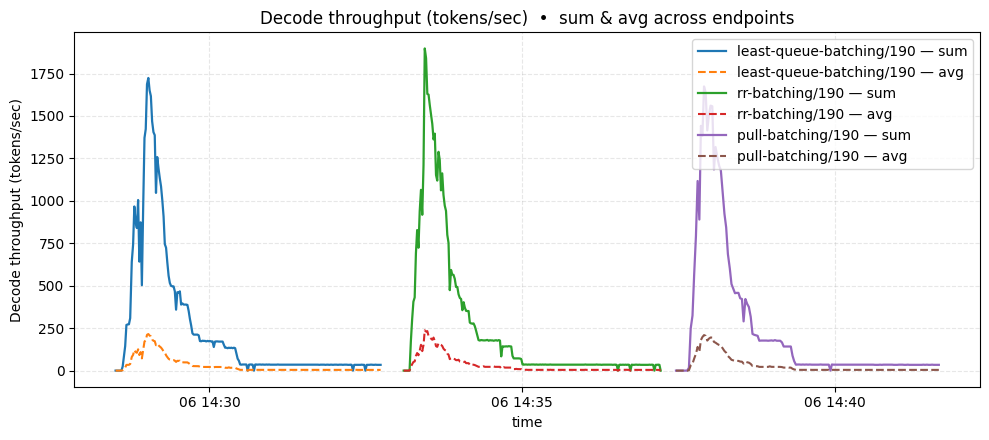

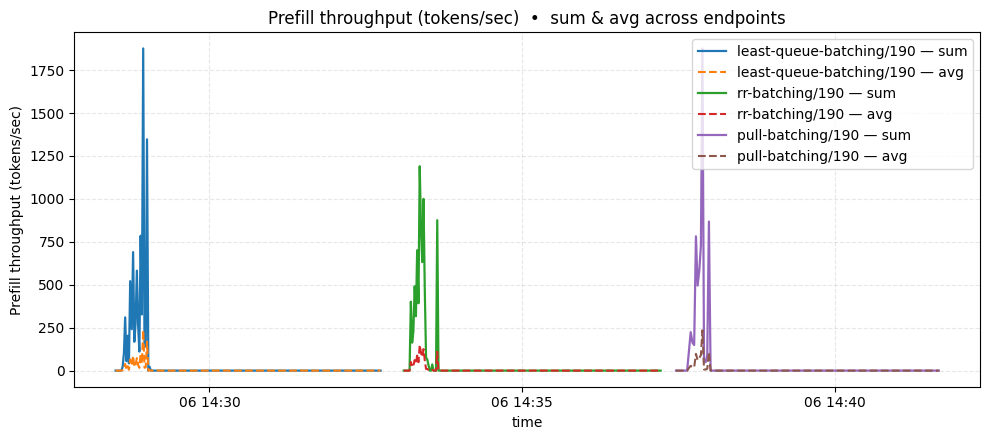

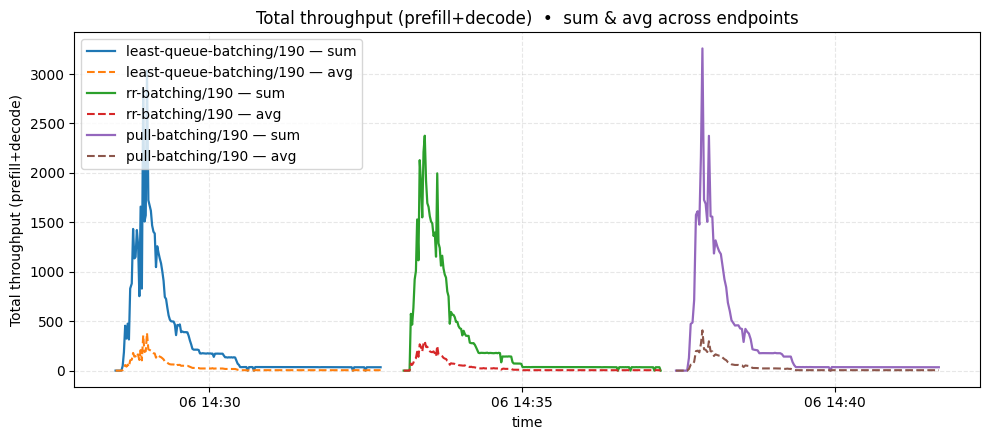

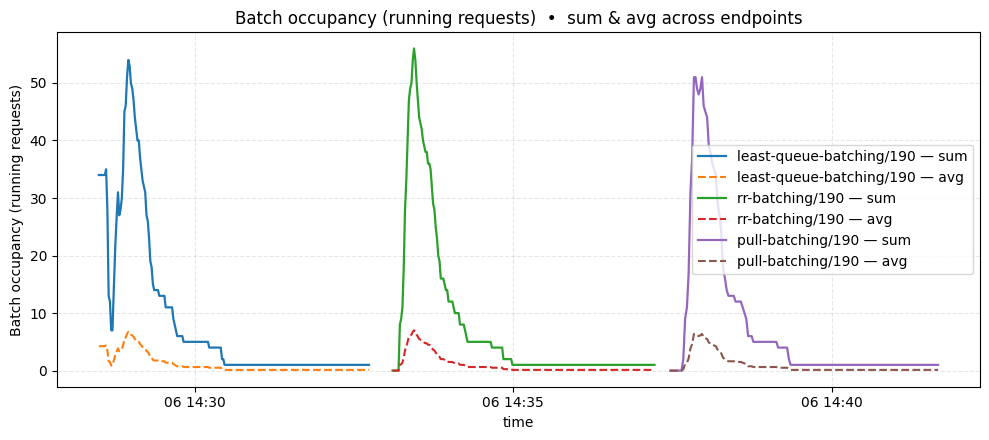

In [24]:
# Cell 5 — Compare methods: SUM (solid) + AVG (dashed) on same figure, robust tz handling
import matplotlib.pyplot as plt
import pandas as pd

def _to_naive_utc_index(idx):
    """Ensure a tz-naive datetime index (convert tz-aware -> UTC -> naive)."""
    idx = pd.to_datetime(idx, errors="coerce")
    if getattr(idx, "tz", None) is not None:
        # If it's tz-aware, convert to UTC then drop tz info
        try:
            idx = idx.tz_convert("UTC")
        except TypeError:
            # If it's tz-naive but pandas thinks it's tz-aware, fall back to localize
            idx = idx.tz_localize("UTC")
        idx = idx.tz_localize(None)
    return idx

def plot_compare_methods_sum_vs_avg(metric_key: str, title: str):
    plt.figure(figsize=(10, 4.5))
    any_plotted = False

    for method, run_id in EXPERIMENTS:
        exp = load_experiment(method, run_id, base_dir=BASE_DIR)
        mdf = exp.get("metrics")
        if mdf is None or mdf.empty:
            continue

        wide = make_wide_from_metrics_raw(mdf, metric_key)
        if wide.empty:
            continue

        # Normalize the index once
        wide = wide.copy()
        wide.index = _to_naive_utc_index(wide.index)
        wide = wide.sort_index()

        s_sum = wide["sum_all_endpoints"].copy()
        s_avg = wide["avg_all_endpoints"].copy()

        # Optional smoothing
        if SMOOTH_N and SMOOTH_N > 1:
            s_sum = s_sum.rolling(SMOOTH_N, min_periods=1).mean()
            s_avg = s_avg.rolling(SMOOTH_N, min_periods=1).mean()

        # Plot both on same axes (sum emphasized)
        plt.plot(s_sum.index, s_sum.values, label=f"{method}/{run_id} — sum", linewidth=1.6)
        plt.plot(s_avg.index, s_avg.values, linestyle="--", label=f"{method}/{run_id} — avg")

        any_plotted = True

    plt.title(f"{title}  •  sum & avg across endpoints")
    plt.xlabel("time")
    plt.ylabel(title)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()

    if not any_plotted:
        plt.close()
        print(f"[skip] No data for '{metric_key}' (sum/avg).")

# Make one figure per metric
for mkey, nice in METRICS_TO_WIDE:
    plot_compare_methods_sum_vs_avg(mkey, nice)


In [25]:
# Cell 7 — Summarize with only avg_sum and avg_avg (no total_sum, total_avg)
import numpy as np
import pandas as pd
from IPython.display import display

# Option to toggle between sum and average per endpoint
SHOW_SUM = True  # Set to False if you want average instead of sum

def _summarize_sum_and_avg_over_time(wide: pd.DataFrame) -> dict:
    """
    Summarize the time-averaged sum and average across all endpoints.
    """
    # We need to extract both the sum and average across endpoints over time
    sum_series = wide["sum_all_endpoints"].copy()
    avg_series = wide["avg_all_endpoints"].copy()

    # Calculate time averages for both
    sum_avg = sum_series.mean()
    avg_avg = avg_series.mean()

    # Return the summary metrics (only avg_sum and avg_avg)
    return {
        "avg_sum": sum_avg,  # time-averaged sum across all endpoints
        "avg_avg": avg_avg,  # time-averaged avg across all endpoints
    }

def summarize_experiments(EXPERIMENTS, metrics, agg_col=AGG_COL, show_sum=True) -> pd.DataFrame:
    rows = []
    for metric_key, nice_title in metrics:
        for method, run_id in EXPERIMENTS:
            exp = load_experiment(method, run_id, base_dir=BASE_DIR)
            s = get_metric_series(exp, metric_key, agg_col)
            if s is None or s.empty:
                continue

            # Compute the wide format (full per-endpoint metrics)
            wide = make_wide_from_metrics_raw(exp.get("metrics", pd.DataFrame()), metric_key)
            if wide.empty:
                continue

            # Get the summary stats: avg_sum, avg_avg
            stats = _summarize_sum_and_avg_over_time(wide)

            rows.append({
                "method": method,
                "run_id": run_id,
                "metric": metric_key,
                "label": nice_title,
                **stats,
            })

    df = pd.DataFrame(rows)
    return df.sort_values(["metric", "method", "run_id"]).reset_index(drop=True)

# Run the summary
EXPT_SUMMARY = summarize_experiments(EXPERIMENTS, METRICS_TO_WIDE, agg_col=AGG_COL, show_sum=SHOW_SUM)

# Pretty print per metric, showing only avg_sum and avg_avg
_fmt = {"avg_sum": "{:,.2f}", "avg_avg": "{:,.2f}"}

for mkey, title in METRICS_TO_WIDE:
    sub = EXPT_SUMMARY[EXPT_SUMMARY["metric"] == mkey]
    if sub.empty: 
        continue
    print(f"\n### {title}  •  ({AGG_COL.replace('_',' ')})")
    display(
        sub[["method", "run_id", "avg_sum", "avg_avg"]]
        .style.format(_fmt)
    )



### Decode throughput (tokens/sec)  •  (avg all endpoints)


,method,run_id,avg_sum,avg_avg
0,least-queue-batching,190,241.04,30.48
1,pull-batching,190,249.85,31.63
2,rr-batching,190,250.13,31.97



### Prefill throughput (tokens/sec)  •  (avg all endpoints)


,method,run_id,avg_sum,avg_avg
3,least-queue-batching,190,39.01,4.89
4,pull-batching,190,40.10,5.03
5,rr-batching,190,38.61,4.83



### Total throughput (prefill+decode)  •  (avg all endpoints)


,method,run_id,avg_sum,avg_avg
9,least-queue-batching,190,280.05,35.11
10,pull-batching,190,289.95,36.26
11,rr-batching,190,288.74,36.60



### Batch occupancy (running requests)  •  (avg all endpoints)


,method,run_id,avg_sum,avg_avg
6,least-queue-batching,190,8.73,1.09
7,pull-batching,190,7.67,0.96
8,rr-batching,190,7.87,0.98


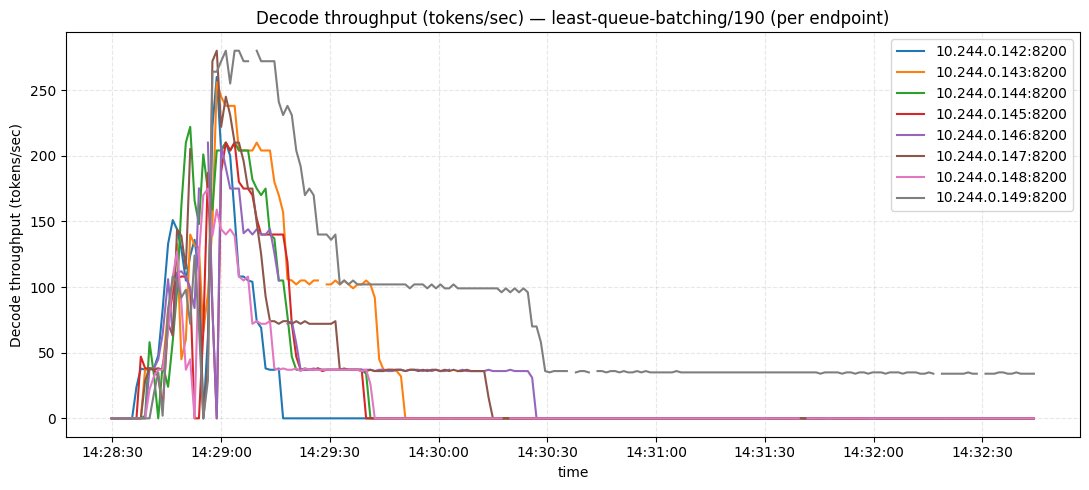

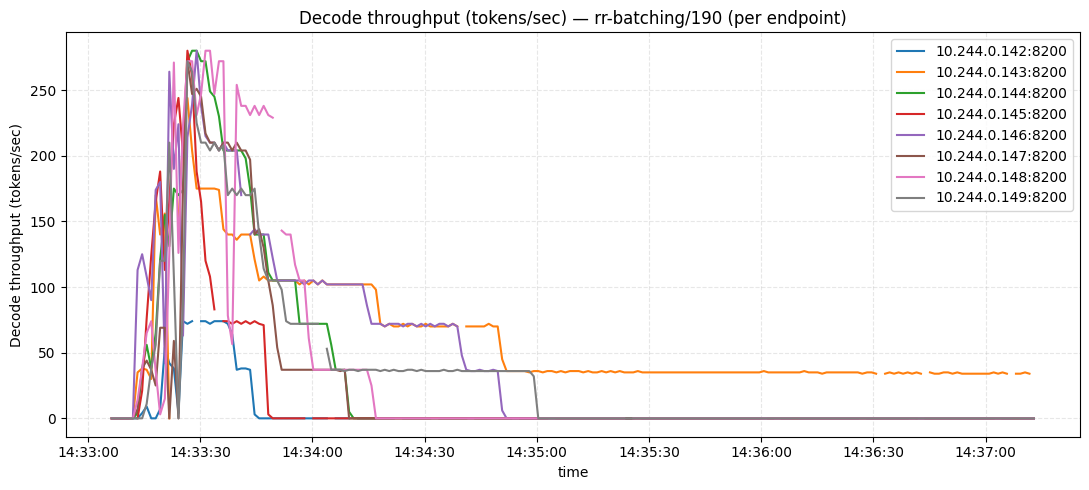

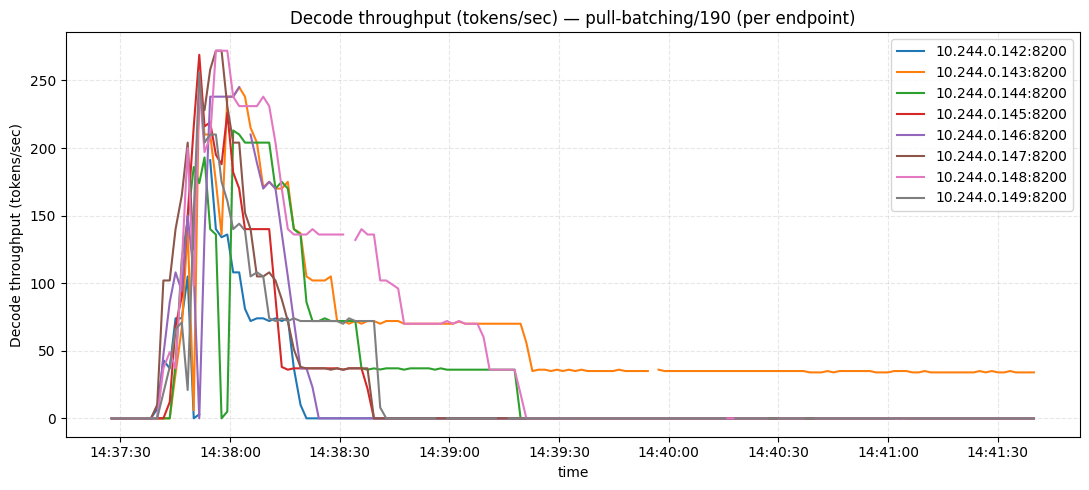

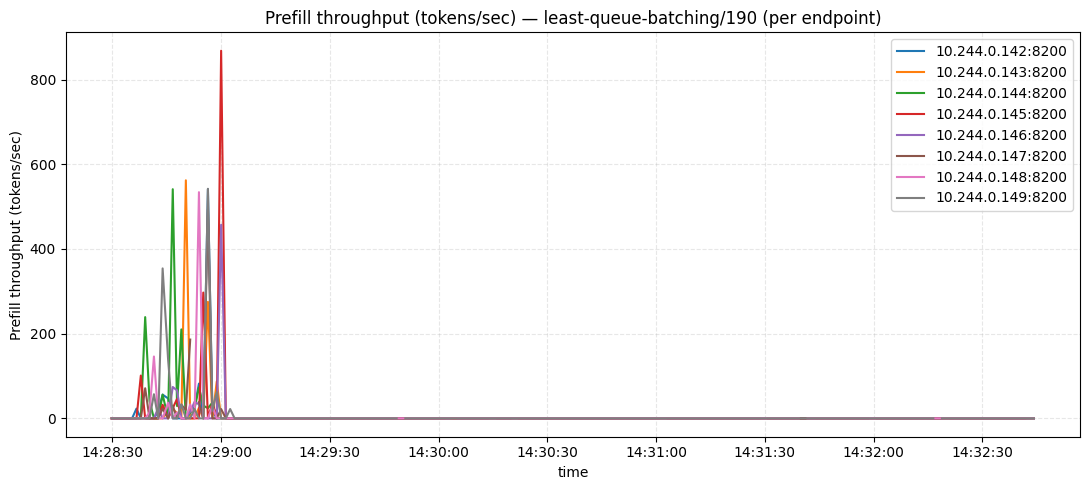

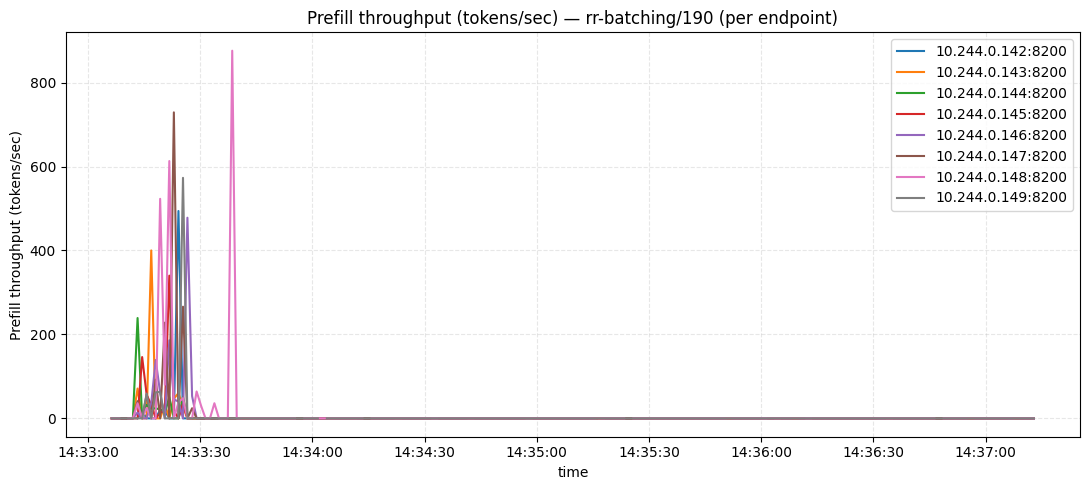

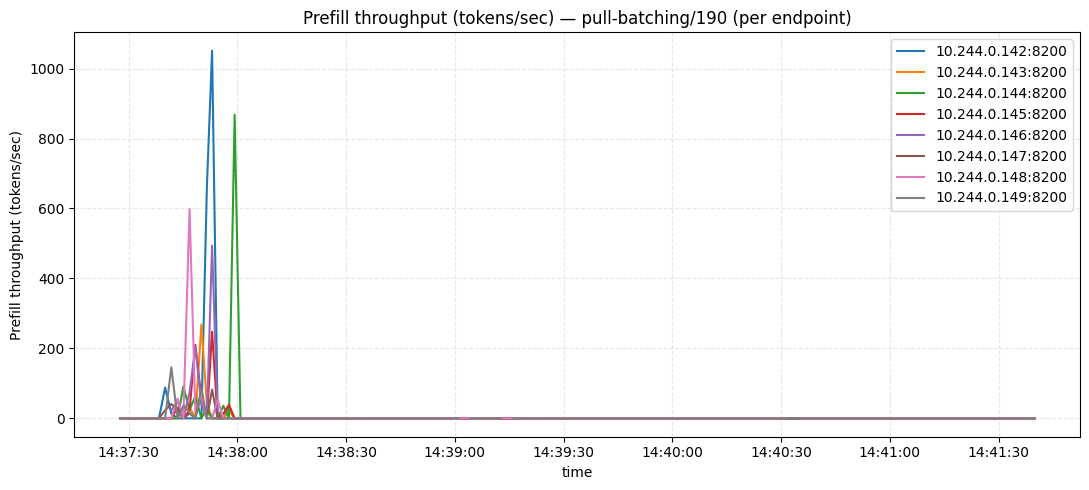

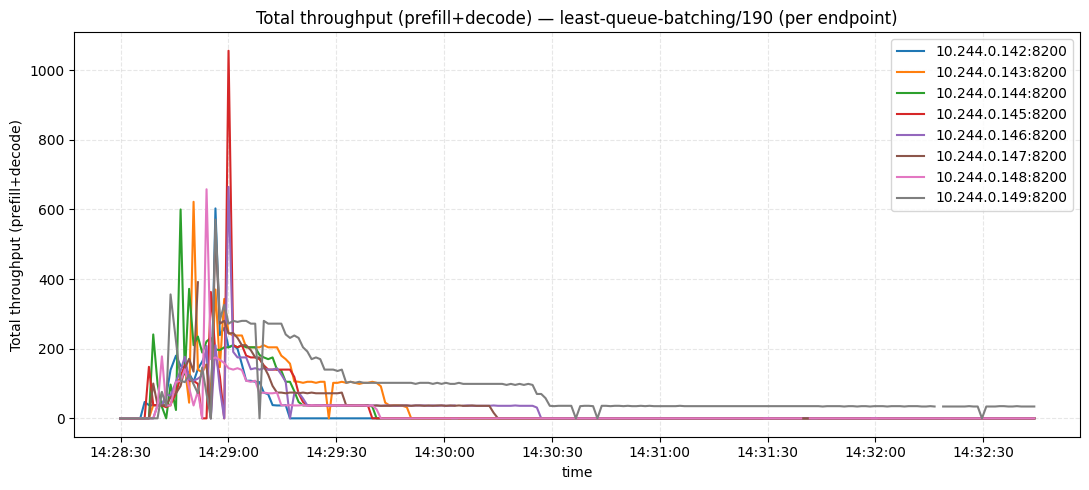

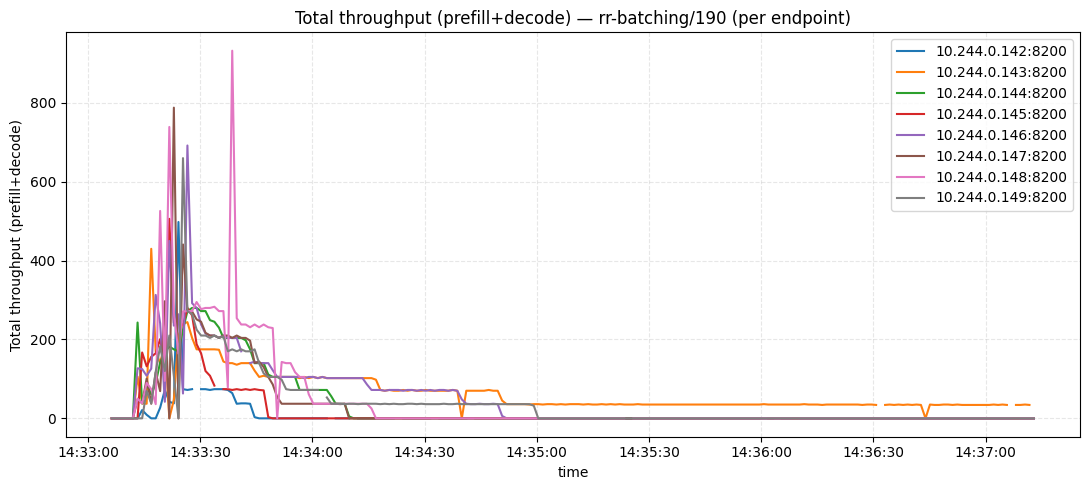

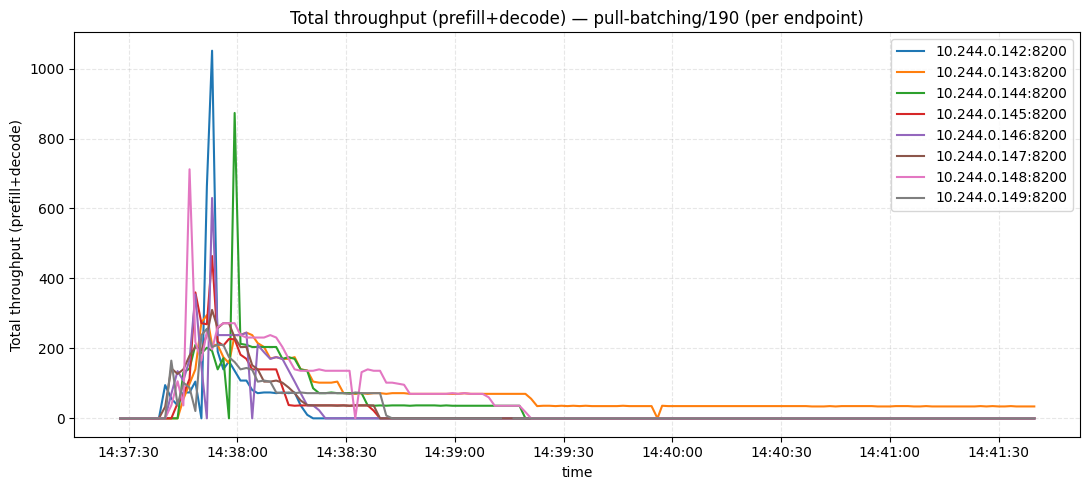

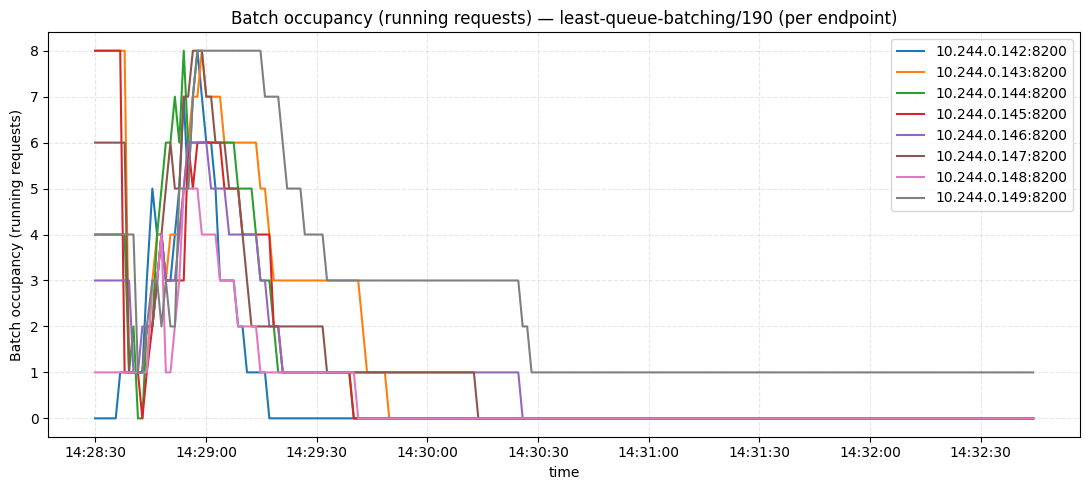

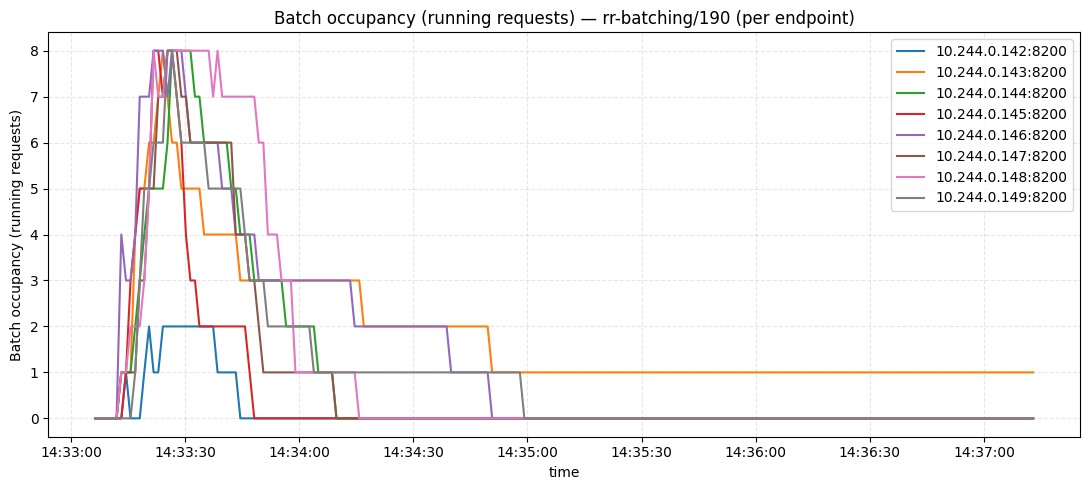

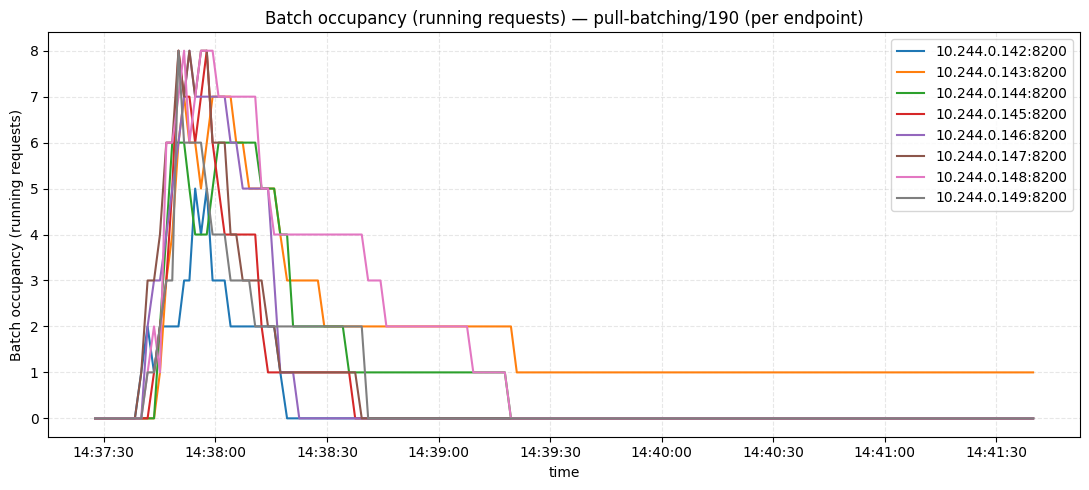

In [ ]:
# Cell 5b — Per-endpoint plots (non-aggregated): one figure per (metric, method/run)
import matplotlib.pyplot as plt
import pandas as pd

def plot_per_endpoint_for_all_methods(metric_key: str, title: str):
    for method, run_id in EXPERIMENTS:
        wide = WIDES.get((method, run_id, metric_key))
        if wide is None or wide.empty:
            continue

        # tz-safe index + order
        wide = wide.copy()
        wide.index = _to_naive_utc_index(wide.index)
        wide = wide.sort_index()

        # all endpoint columns (exclude aggregates)
        endpoint_cols = [c for c in wide.columns if c not in ("sum_all_endpoints", "avg_all_endpoints")]
        endpoint_cols = [c for c in endpoint_cols if wide[c].notna().any()]
        if not endpoint_cols:
            continue

        plt.figure(figsize=(11, 5))
        for col in endpoint_cols:
            s = wide[col]
            if SMOOTH_N and SMOOTH_N > 1:
                s = s.rolling(SMOOTH_N, min_periods=1).mean()
            plt.plot(s.index, s.values, label=col)

        plt.title(f"{title} — {method}/{run_id} (per endpoint)")
        plt.xlabel("time")
        plt.ylabel(title)
        plt.grid(True, linestyle="--", alpha=0.3)
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()

# Make figures: per-endpoint lines for each metric, separated by method/run
for mkey, nice in METRICS_TO_WIDE:
    plot_per_endpoint_for_all_methods(mkey, nice)


In [ ]:
# Cell 5d — Fully self-contained: compute BALANCES + show Jain & CV tables
import numpy as np
import pandas as pd
from IPython.display import display

# --- Helpers to compute balance metrics across endpoints ---
def _safe_array(vals):
    a = np.asarray(vals, dtype="float64")
    a = np.where(np.isfinite(a) & (a >= 0), a, 0.0)
    return a

def _jain_fairness(x: np.ndarray) -> float:
    x = _safe_array(x)
    s1, s2, n = x.sum(), (x * x).sum(), x.size
    if n == 0 or s1 == 0 or s2 == 0:
        return np.nan
    return (s1 * s1) / (n * s2)

def _coef_var(x: np.ndarray) -> float:
    x = _safe_array(x)
    m = x.mean()
    if m == 0:
        return np.nan
    return x.std(ddof=0) / m

def _endpoint_columns(wide: pd.DataFrame):
    return [c for c in wide.columns if c not in ("sum_all_endpoints", "avg_all_endpoints")]

def compute_balance_timeseries(wide: pd.DataFrame) -> pd.DataFrame:
    """Compute Jain + CV for each timestamp from per-endpoint metric DataFrame."""
    if wide is None or wide.empty:
        return pd.DataFrame()

    ep_cols = _endpoint_columns(wide)
    if not ep_cols:
        return pd.DataFrame()

    idx = pd.to_datetime(wide.index, errors="coerce")
    if getattr(idx, "tz", None) is not None:
        try:
            idx = idx.tz_convert("UTC")
        except TypeError:
            idx = idx.tz_localize("UTC")
        idx = idx.tz_localize(None)

    W = wide.copy()
    W.index = idx
    W = W.sort_index()

    rows = []
    for ts, row in W.iterrows():
        x = row[ep_cols].to_numpy(dtype="float64")
        rows.append({
            "ts": ts,
            "jain": _jain_fairness(x),
            "cv": _coef_var(x),
        })
    return pd.DataFrame(rows).set_index("ts")

# --- Compute BALANCES from WIDES ---
BALANCES = {}
for method, run_id in EXPERIMENTS:
    for metric_key, _label in METRICS_TO_WIDE:
        wide = WIDES.get((method, run_id, metric_key))
        if wide is not None and not wide.empty:
            BALANCES[(method, run_id, metric_key)] = compute_balance_timeseries(wide)

print(f"Computed BALANCES for {len(BALANCES)} (method, run, metric) combos.")

# --- Summarize Jain & CV per metric/method ---
def summarize_jain_cv(BALANCES: dict) -> pd.DataFrame:
    rows = []
    for (method, run_id, metric_key), bal in BALANCES.items():
        if bal is None or bal.empty:
            continue
        cv_series = bal["cv"].dropna() if "cv" in bal.columns else pd.Series(dtype=float)
        rows.append({
            "method": method,
            "run_id": run_id,
            "metric": metric_key,
            "jain_mean": float(np.nanmean(bal["jain"])) if "jain" in bal.columns else np.nan,
            "jain_min": float(np.nanmin(bal["jain"])) if "jain" in bal.columns else np.nan,
            "cv_mean": float(np.nanmean(cv_series)) if not cv_series.empty else np.nan,
            "cv_p95": float(np.nanpercentile(cv_series, 95)) if not cv_series.empty else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["metric","method","run_id"]).reset_index(drop=True)

JAIN_CV_SUMMARY = summarize_jain_cv(BALANCES)

# --- Display results per metric ---
fmt = {"jain_mean":"{:.3f}", "jain_min":"{:.3f}", "cv_mean":"{:.3f}", "cv_p95":"{:.3f}"}
metrics_order = [m for m, _ in METRICS_TO_WIDE]
labels = dict(METRICS_TO_WIDE)

for mkey in metrics_order:
    sub = JAIN_CV_SUMMARY[JAIN_CV_SUMMARY["metric"] == mkey]
    if sub.empty:
        continue
    print(f"\n### {labels.get(mkey, mkey)} — Jain (↑ better) & CV (↓ better)")
    display(sub[["method","run_id","jain_mean","jain_min","cv_mean","cv_p95"]].style.format(fmt))

# --- Overall mean Jain & CV per method (across all metrics) ---
METHOD_OVERALL = (
    JAIN_CV_SUMMARY
    .groupby(["method","run_id"], as_index=False)
    .agg(jain_mean_overall=("jain_mean","mean"),
         cv_mean_overall=("cv_mean","mean"))
    .sort_values(["method","run_id"])
)

print("\n### Overall per method (across metrics): mean Jain ↑, mean CV ↓")
display(METHOD_OVERALL.style.format({"jain_mean_overall":"{:.3f}", "cv_mean_overall":"{:.3f}"}))


Computed BALANCES for 12 (method, run, metric) combos.

### Decode throughput (tokens/sec) — Jain (↑ better) & CV (↓ better)


,method,run_id,jain_mean,jain_min,cv_mean,cv_p95
0,least-queue-batching,190,0.315,0.125,1.921,2.646
1,pull-batching,190,0.315,0.125,1.926,2.646
2,rr-batching,190,0.313,0.125,1.900,2.646



### Prefill throughput (tokens/sec) — Jain (↑ better) & CV (↓ better)


,method,run_id,jain_mean,jain_min,cv_mean,cv_p95
3,least-queue-batching,190,0.259,0.125,1.851,2.646
4,pull-batching,190,0.266,0.125,1.797,2.646
5,rr-batching,190,0.235,0.125,1.983,2.646



### Total throughput (prefill+decode) — Jain (↑ better) & CV (↓ better)


,method,run_id,jain_mean,jain_min,cv_mean,cv_p95
9,least-queue-batching,190,0.302,0.125,1.944,2.646
10,pull-batching,190,0.310,0.125,1.935,2.646
11,rr-batching,190,0.309,0.125,1.907,2.646



### Batch occupancy (running requests) — Jain (↑ better) & CV (↓ better)


,method,run_id,jain_mean,jain_min,cv_mean,cv_p95
6,least-queue-batching,190,0.327,0.125,1.892,2.646
7,pull-batching,190,0.316,0.125,1.931,2.646
8,rr-batching,190,0.315,0.125,1.909,2.646



### Overall per method (across metrics): mean Jain ↑, mean CV ↓


,method,run_id,jain_mean_overall,cv_mean_overall
0,least-queue-batching,190,0.301,1.902
1,pull-batching,190,0.302,1.897
2,rr-batching,190,0.293,1.925
